# 1-DOF MCP Static Model: Equilibrium Angle Under Applied Actuator Torque

### 1. _How does the equilibrium angle of the index-finger MCP joint change as applied actuator torque increases in a 1-DOF quasi-static model?_

#### _What behavior am I trying to understand?_

#### - the static balance between actuator torque pushing the joint and passive joint stiffness resisting it

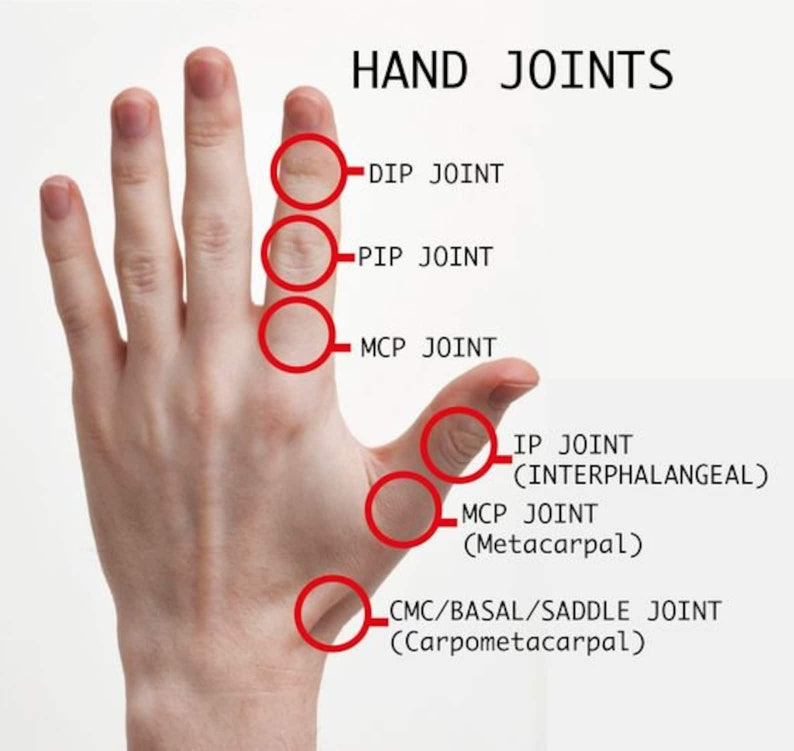

### In plain language, the behavior is:

* if I push harder with the actuator, how far does the MCP joint settle?
* if the joint is stiffer, how much harder does the actuator need to work?
* what torque range gives a useful angle range?


# 2. Assumptions

* single MCP joint only
* planar flexion-extension only
* quasi-static, so inertia and acceleration are neglected
* the actuator is represented as an applied joint torque
* passive joint behavior is modeled as a linear torsional spring about a neutral angle
* gravity, tendon routing, and contact with objects or the thumb are ignored


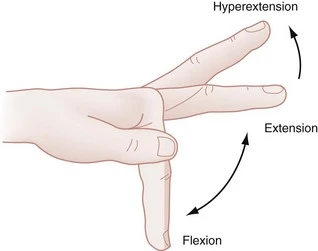

* Flexion is positive and extension is negative


# 3. Torque Balance:

* The actuator applies a torque that rotates the MCP joint.
* The passive tissues around the joint resist that motion with a restoring torque.
* As the joint angle increases, the passive resisting torque increases.
* Equilibrium occurs when the actuator torque and passive resisting torque are equal in magnitude and opposite in direction.
* At that point, the net torque on the joint is zero, so the joint settles at that angle in the quasi-static model.


# 4. Input, Response Variable, and Parameters

Input
* applied actuator torque = `τ_app` or `tau_app`

Response variable
* joint angle = `θ` or `theta`

Parameters
* joint stiffness = `k`
* neutral/rest angle of the joint = `θ_0` 

## 4. Governing Equation

$$
\sum \tau = 0
\;\Rightarrow\;
\tau_{\mathrm{app}} + \tau_{\mathrm{passive}}(\theta) = 0
\;\Rightarrow\;
\tau_{\mathrm{app}} - k(\theta - \theta_0) = 0
$$


#### Solving for $\theta$

$$
\tau_{\mathrm{app}} - k(\theta - \theta_0) = 0
\;\Rightarrow\;
k(\theta - \theta_0) = \tau_{\mathrm{app}}
\;\Rightarrow\;
\theta - \theta_0 = \frac{\tau_{\mathrm{app}}}{k}
\;\Rightarrow\;
\theta = \frac{\tau_{\mathrm{app}}}{k} + \theta_0
$$


## 5. First Extension: Sweep Passive Joint Stiffness

We keep the same equilibrium equation,

$$
\theta = \frac{\tau_{\mathrm{app}}}{k} + \theta_0
$$

and compare several values of `k`.

* lower `k` means a more compliant joint, so the same applied torque produces a larger equilibrium angle
* higher `k` means a stiffer joint, so more torque is required to reach the same angle
* this is still the same linear passive-joint model; only the stiffness parameter is changing


In [4]:
import numpy as np
import plotly.graph_objects as go

def equilibrium_angle_linear_passive(tau_app, k, theta_0=0.0):
    """Static equilibrium angle for a linear passive MCP model."""
    return tau_app / k + theta_0

def required_torque_linear_passive(theta_target, k, theta_0=0.0):
    """Required actuator torque to hold a target angle in the same model."""
    return k * (theta_target - theta_0)

# Parameters
theta_0 = 0.0
stiffness_values = np.array([0.04, 0.08, 0.12])  # passive joint stiffness [N·m/rad]
mcp_interpretation_window_deg = (0.0, 80.0)  # provisional angle band for interpretation
angle_plot_range_deg = (0.0, 120.0)  # keep angle extent consistent across plots

# Input torque sweep
tau_app = np.linspace(0.0, 0.08, 100)  # applied actuator torque [N·m]
theta_target_deg = np.linspace(angle_plot_range_deg[0], angle_plot_range_deg[1], 120)  # target MCP angle [deg]
theta_target_rad = np.deg2rad(theta_target_deg)

# Compute one equilibrium curve for each passive stiffness value.
theta_eq_by_k_deg = {}
for k in stiffness_values:
    theta_eq = equilibrium_angle_linear_passive(tau_app, k=k, theta_0=theta_0)
    theta_eq_by_k_deg[k] = np.rad2deg(theta_eq)

# Compute the inverse relationship for the same stiffness values.
tau_required_by_k = {}
for k in stiffness_values:
    tau_required_by_k[k] = required_torque_linear_passive(theta_target_rad, k=k, theta_0=theta_0)


In [ ]:
fig = go.Figure()

for k in stiffness_values:
    fig.add_trace(
        go.Scatter(
            x=tau_app,
            y=theta_eq_by_k_deg[k],
            mode="lines",
            name=f"k = {k:.2f} N·m/rad",
            hovertemplate="τ_app = %{x:.3f} N·m<br>θ_eq = %{y:.1f} deg<br>%{fullData.name}<extra></extra>",
        )
    )

fig.add_hrect(
    y0=mcp_interpretation_window_deg[0],
    y1=mcp_interpretation_window_deg[1],
    fillcolor="lightgreen",
    opacity=0.12,
    line_width=0,
    annotation_text="provisional interpretation band",
    annotation_position="top left",
)

fig.update_layout(
    title="1-DOF MCP Static Model: Effect of Passive Joint Stiffness",
    xaxis_title="Applied actuator torque, τ_app [N·m]",
    yaxis_title="Equilibrium MCP angle, θ_eq [deg]",
    legend_title_text="Passive stiffness",
    template="plotly_white",
)

fig.update_xaxes(showgrid=True)
fig.update_yaxes(showgrid=True, range=list(angle_plot_range_deg))
fig.show()

## 6. Inverse View: Required Torque For A Target Angle

Now we solve the same equation in the other direction.

Starting from

$$
\tau_{\mathrm{app}} = k(\theta - \theta_0)
$$

if we choose a target angle $\theta_{\mathrm{target}}$, the required holding torque is

$$
\tau_{\mathrm{required}} = k(\theta_{\mathrm{target}} - \theta_0)
$$

This is the same model, but it is often the more useful control-oriented view.

* forward view: if I apply this torque, where does the joint settle?
* inverse view: if I want this angle, how much torque must the actuator provide?

For now, we also mark a provisional MCP angle band only as an interpretation aid.
It is not yet a literature-justified anatomical limit; it is just a way to see when the
simple linear model starts predicting angles outside the range we currently want to focus on.


In [ ]:
fig = go.Figure()

for k in stiffness_values:
    fig.add_trace(
        go.Scatter(
            x=theta_target_deg,
            y=tau_required_by_k[k],
            mode="lines",
            name=f"k = {k:.2f} N·m/rad",
            hovertemplate="θ_target = %{x:.1f} deg<br>τ_required = %{y:.3f} N·m<br>%{fullData.name}<extra></extra>",
        )
    )

fig.add_vrect(
    x0=mcp_interpretation_window_deg[0],
    x1=mcp_interpretation_window_deg[1],
    fillcolor="lightgreen",
    opacity=0.12,
    line_width=0,
    annotation_text="provisional interpretation band",
    annotation_position="top left",
)

fig.update_layout(
    title="1-DOF MCP Static Model: Required Torque For A Target Angle",
    xaxis_title="Target MCP angle, θ_target [deg]",
    yaxis_title="Required actuator torque, τ_required [N·m]",
    legend_title_text="Passive stiffness",
    template="plotly_white",
)

fig.update_xaxes(showgrid=True, range=list(angle_plot_range_deg))
fig.update_yaxes(showgrid=True)
fig.show()